In [64]:
import pandas as pd
import numpy as np
from textblob import TextBlob
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import math
from collections import Counter
import re
from scipy import stats

In [65]:
df = pd.read_csv("youtube1.csv")

In [66]:
df.head()

,index,video_id,trending_date,title,channel_title,category_id,publish_date,time_frame,published_day_of_week,publish_country,tags,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,video_error_or_removed
0,0.0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22.0,13/11/2017,17:00 to 17:59,Monday,NaN,SHANtell martin,748374.0,57527.0,2966.0,15954.0,False,NaN,NaN
1,1.0,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,NaN,NaN,NaN,Monday,US,"last week tonight trump presidency|""last week ...",2418783.0,97185.0,6146.0,12703.0,False,False,False
2,2.0,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23.0,12/11/2017,19:00 to 19:59,NaN,NaN,"racist superman|""rudy""""|""""mancuso""""|""""king""""|""...",3191434.0,146033.0,5339.0,8181.0,False,False,NaN
3,3.0,puqaWrEC7tY,17.14.11,NaN,Good Mythical Morning,24.0,13/11/2017,11:00 to 11:59,NaN,NaN,"rhett and link|""gmm""""|""""good mythical morning""...",343168.0,10172.0,666.0,NaN,False,False,False
4,NaN,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24.0,12/11/2017,18:00 to 18:59,Sunday,US,"ryan|""higa""""|""""higatv""""|""""nigahiga""""|""""i dare ...",NaN,NaN,1989.0,17518.0,False,False,False


In [67]:
df.shape

(161470, 18)

In [68]:
df.columns

Index(['index', 'video_id', 'trending_date', 'title', 'channel_title',
       'category_id', 'publish_date', 'time_frame', 'published_day_of_week',
       'publish_country', 'tags', 'views', 'likes', 'dislikes',
       'comment_count', 'comments_disabled', 'ratings_disabled',
       'video_error_or_removed'],
      dtype='object')

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161470 entries, 0 to 161469
Data columns (total 18 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   index                   129338 non-null  float64
 1   video_id                129312 non-null  object 
 2   trending_date           129307 non-null  object 
 3   title                   129353 non-null  object 
 4   channel_title           129002 non-null  object 
 5   category_id             129134 non-null  float64
 6   publish_date            129126 non-null  object 
 7   time_frame              128958 non-null  object 
 8   published_day_of_week   129254 non-null  object 
 9   publish_country         129161 non-null  object 
 10  tags                    129343 non-null  object 
 11  views                   128782 non-null  float64
 12  likes                   129274 non-null  float64
 13  dislikes                129244 non-null  float64
 14  comment_count       

In [70]:
df.isnull().sum()

index                     32132
video_id                  32158
trending_date             32163
title                     32117
channel_title             32468
category_id               32336
publish_date              32344
time_frame                32512
published_day_of_week     32216
publish_country           32309
tags                      32127
views                     32688
likes                     32196
dislikes                  32226
comment_count             32257
comments_disabled         32494
ratings_disabled          32072
video_error_or_removed    32477
dtype: int64

removed index...extra burden and complier will generate its own index.

In [71]:
# Drop the irrelevant 'index' column
if 'index' in df.columns:
    df = df.drop(columns=['index'])

Step 2: Remove Rows with Missing Data
Your dataset has about 32,000 missing values in critical columns like views, likes, and publish_date. You cannot analyze a video if you don't know how many views it got or when it was published.

Action: Drop any row where these critical values are missing.

Dropping the missing values:
Videoid : it is unique and primary key
title: it should be unique 
channel title: 2 channel cannot have same name
views: fake views cant be there
likes: fake likes cant be there
dislikes: same
comment: same
category_id: primary key
publish date: details may get wrong 
trending date: details may get wrong

In [72]:
# List of columns that MUST have data
critical_cols = ['video_id','title', 'channel_title','views', 'likes', 'dislikes', 'comment_count', 
                 'category_id', 'publish_date', 'trending_date']

# Drop rows that have NaN (missing values) in these columns
df = df.dropna(subset=critical_cols)

Fillna:
comment : if data is missing we consider it and fill it with false


In [73]:
# 2. FILL Boolean Columns (Assume False if missing)
# comments_disabled, ratings_disabled, video_error_or_removed
bool_cols = ['comments_disabled', 'ratings_disabled', 'video_error_or_removed']
for col in bool_cols:
    df[col] = df[col].fillna(False)

C:\Users\hp\AppData\Local\Temp\ipykernel_6116\813494263.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(False)


Tags: 
if there is no we fill it with "no tag"
timeframe: if i upload  a video at 8.30pm then the timeframe is  8pm to 9pm
if there is no timeframe we fill it with "unknown"

In [74]:
# 4. FILL Text Columns
df['tags'] = df['tags'].fillna("No Tags")
df['time_frame'] = df['time_frame'].fillna("Unknown")

publish country we use mode and filled the missing value with the country that has publish more videos(or is repeated)

In [75]:
# Fill Country with the most common value (likely 'US')
most_common_country = df['publish_country'].mode()[0]
df['publish_country'] = df['publish_country'].fillna(most_common_country)

Step 3: Fix Date Formats
The dates are currently stored as text (strings) and are in tricky formats:

trending_date looks like 17.14.11 (YY.DD.MM).

publish_date looks like 13/11/2017 (DD/MM/YYYY).

Action: Convert these columns to proper Python datetime objects so you can sort and plot them later.

we cannot do analysis properly with objkect datatype so we change it into og datatype that is "Datetime"
dropna: if data is not converted we will drop it

In [76]:
# Convert trending_date (Format: Year.Day.Month)
df['trending_date'] = pd.to_datetime(df['trending_date'], format='%y.%d.%m', errors='coerce')

# Convert publish_date (Format: Day/Month/Year)
df['publish_date'] = pd.to_datetime(df['publish_date'], format='%d/%m/%Y', errors='coerce')

# Drop any rows where the date conversion failed
df = df.dropna(subset=['trending_date', 'publish_date'])

dt: date time accessor, helps to access the day of week based on publish date
there is no missing values in publish date so no need to drop also no need to use mode


In [77]:
# 3. DERIVE Day of Week
# We calculate this from the valid 'publish_date' we created earlier
df['published_day_of_week'] = df['publish_date'].dt.day_name()

Step 4: Fix Number Types
Currently, your views and likes are stored as "floats" (e.g., 748374.0). They should be whole integers (e.g., 748374). Also, category_id is a category, not a number you do math on, so it should be a text string.

Action: Convert numerical columns to int and category IDs to string.

views, likes,dislikes,comment cannot be in decimal so changed it into integer
category id (float) should be in strings but here it is in float so converted it into int and then to strings

In [78]:
# Convert metrics to integers
int_cols = ['views', 'likes', 'dislikes', 'comment_count']
df[int_cols] = df[int_cols].astype(int)

# Convert category_id to string (it's a label, not a quantity)
df['category_id'] = df['category_id'].astype(int).astype(str)

strip = space cleaning in the beginning and ending of the title

Step 5: Clean Text Data
Text fields often have accidental spaces at the beginning or end (e.g., " CaseyNeistat " instead of "CaseyNeistat"). This can cause duplicate entries for the same channel.

Action: "Strip" whitespace from text columns.

In [79]:
# Remove leading/trailing spaces
df['title'] = df['title'].str.strip()
df['channel_title'] = df['channel_title'].str.strip()

. Handling Duplicates
The Issue: A video often trends for multiple days, so the same video_id appears multiple times.

Decision: Do you want to analyze how trends change (keep duplicates) or just unique videos (remove duplicates)?

Option A (Keep Duplicates): Good for time-series analysis (e.g., "how long do videos stay trending?").

Option B (Remove Duplicates): Good for analyzing content (e.g., "what titles work best?"). We usually keep the last entry because it has the highest view count.

Code to Remove Duplicates (Keeping the row with the most views):


Duplicate Values:
first we have done sorting on the basis of viwes to count the highest views and kept in last
here we drop the duplicate video on  the basis of video id by keeping the video odf higest views and remaining are dropped

In [80]:
# Sort by views so the highest view count is last
df = df.sort_values('views', ascending=True)

# Drop duplicates based on 'video_id', keeping the last (highest view) one
df_unique = df.drop_duplicates(subset=['video_id'], keep='last')

print(f"Original rows: {len(df)}")
print(f"Unique videos: {len(df_unique)}")

Original rows: 17436
Unique videos: 12139


Handling Inconsistent Data
The Issue: Text data can be messy. United States, USA, and usa are the same, but Python sees them as different.

My Check: Your publish_country column has US, GB, FRANCE, CANADA, and nan. This looks mostly clean, but FRANCE is fully uppercase while others are codes.

Action: Standardize text to be consistent.

Code to Fix Inconsistent Text:

DATA CLEANING
first we made everything in uppercase and then converted it into to short form to make a proper format


In [81]:
df['publish_country'].unique()

array(['FRANCE', 'US', 'GB', 'CANADA'], dtype=object)

str.title: makes a proper Tilte that is first letter is capital rest is small

In [82]:
# Standardize Country codes (Make everything uppercase)
df['publish_country'] = df['publish_country'].str.upper()

# Fix specific inconsistencies (Example: 'FRANCE' -> 'FR')
df['publish_country'] = df['publish_country'].replace({'FRANCE': 'FR', 'CANADA': 'CA'})

# Clean Channel Titles (remove extra spaces and make title case)
df['channel_title'] = df['channel_title'].str.strip().str.title()

In [83]:
df.duplicated().sum()

3

In [84]:
df = df.drop_duplicates()

tolist: keeps all object columns in a list
and that entire list is converted into category

In [85]:
# Identify all columns that are currently 'object' (text)
object_cols = df.select_dtypes(include='object').columns.tolist()

# Convert every single one of them to 'category'
for col in object_cols:
    df[col] = df[col].astype('category')

all the things that come under category column will be stroge in category_df variable

In [86]:
category_df = df.select_dtypes(include= 'category')

In [87]:
category_df.describe()

,video_id,title,channel_title,category_id,time_frame,published_day_of_week,publish_country,tags
count,17433,17433,17433,17433,17433,17433,17433,17433
unique,12139,12320,5049,16,25,7,4,9730
top,#NAME?,CÃ©line Dion - Ashes (from the Deadpool 2 Moti...,The Late Show With Stephen Colbert,24,Unknown,Friday,FR,No Tags
freq,192,13,74,4524,3501,3062,7006,3382


In [88]:
numeric_df = df.select_dtypes(include = 'number')

In [89]:
numeric_df.describe()

,views,likes,dislikes,comment_count
count,1.743300e+04,1.743300e+04,1.743300e+04,1.743300e+04
mean,2.488650e+06,6.889599e+04,3.840308e+03,7.678800e+03
std,1.053470e+07,2.477496e+05,3.646744e+04,4.092203e+04
min,3.650000e+02,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.008040e+05,2.004000e+03,8.500000e+01,2.750000e+02
50%,3.978030e+05,1.013100e+04,3.600000e+02,1.166000e+03
75%,1.366823e+06,4.140100e+04,1.407000e+03,4.321000e+03
max,4.026508e+08,5.321402e+06,1.843521e+06,1.506173e+06


In [90]:
Lower_limit = {}
Upper_limit = {}
Outlier_dict = {}

for col in numeric_df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    Lower_limit[col] = Q1 - 1.5 * IQR
    Upper_limit[col] = Q3 + 1.5 * IQR

    Outlier_dict[col] = df[(df[col] < Lower_limit[col]) | (df[col] > Upper_limit[col])]




Boxplot containing outliers

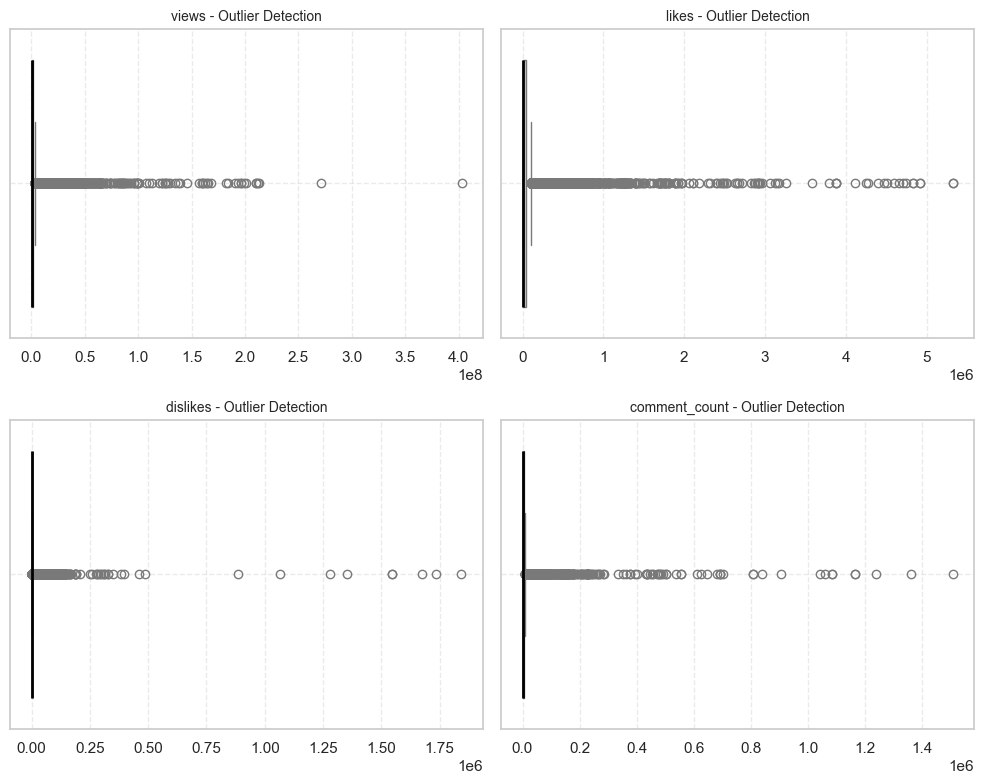

In [91]:
# Get numeric columns
num_cols = numeric_df.columns

# Grid size — adjust as you wish (2x2 gives the layout you showed)
n_cols = 2
n_rows = math.ceil(len(num_cols) / n_cols)

# Create figure and axes grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4 * n_rows))
axes = axes.flatten()  # flatten for easy looping

# Loop through numeric columns and plot
for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='lightblue', medianprops={'color': 'black', 'linewidth': 2})
    axes[i].set_title(f'{col} - Outlier Detection', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].grid(True, linestyle='--', alpha=0.4)

# Remove unused subplots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Capping Outliers: not removing but just hidding

In [92]:
for col in numeric_df:
    df[col] = np.where(df[col] < Lower_limit[col], Lower_limit[col],
              np.where(df[col] > Upper_limit[col], Upper_limit[col], df[col]))

Boxplot without outlier

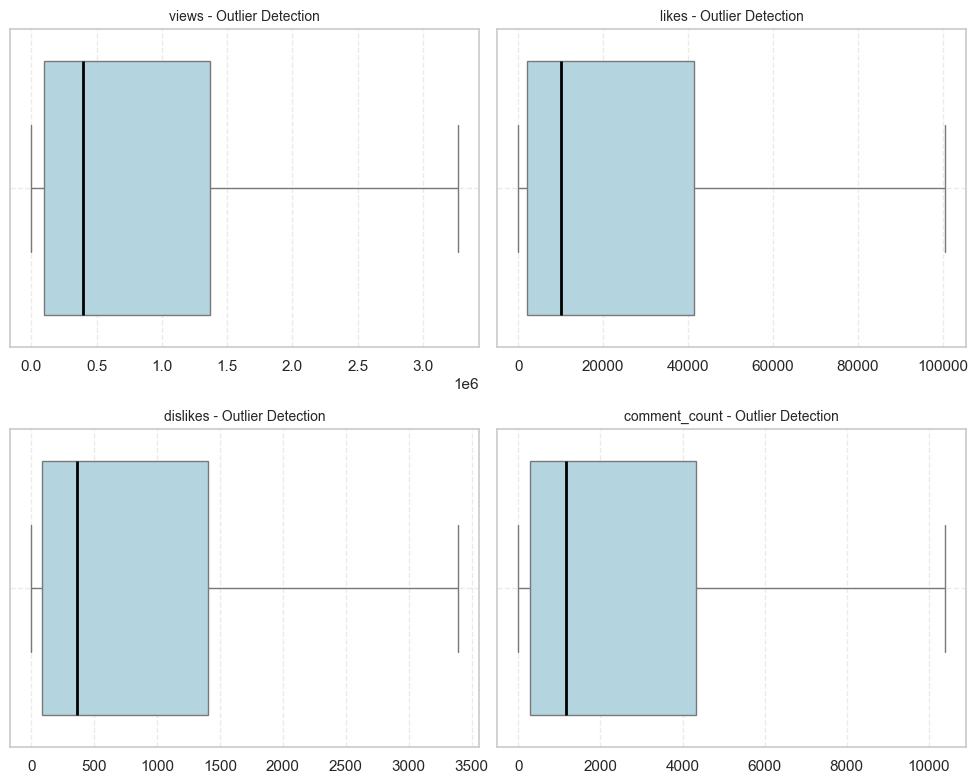

In [93]:
# Get numeric columns
num_cols = numeric_df.columns

# Grid size — adjust as you wish (2x2 gives the layout you showed)
n_cols = 2
n_rows = math.ceil(len(num_cols) / n_cols)

# Create figure and axes grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4 * n_rows))
axes = axes.flatten()  # flatten for easy looping

# Loop through numeric columns and plot
for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='lightblue', medianprops={'color': 'black', 'linewidth': 2})
    axes[i].set_title(f'{col} - Outlier Detection', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].grid(True, linestyle='--', alpha=0.4)

# Remove unused subplots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Univariate Analysis

In [94]:
# Set the visual style
sns.set(style="whitegrid")

we have only 4 numerical columns so we did analysis for all 4

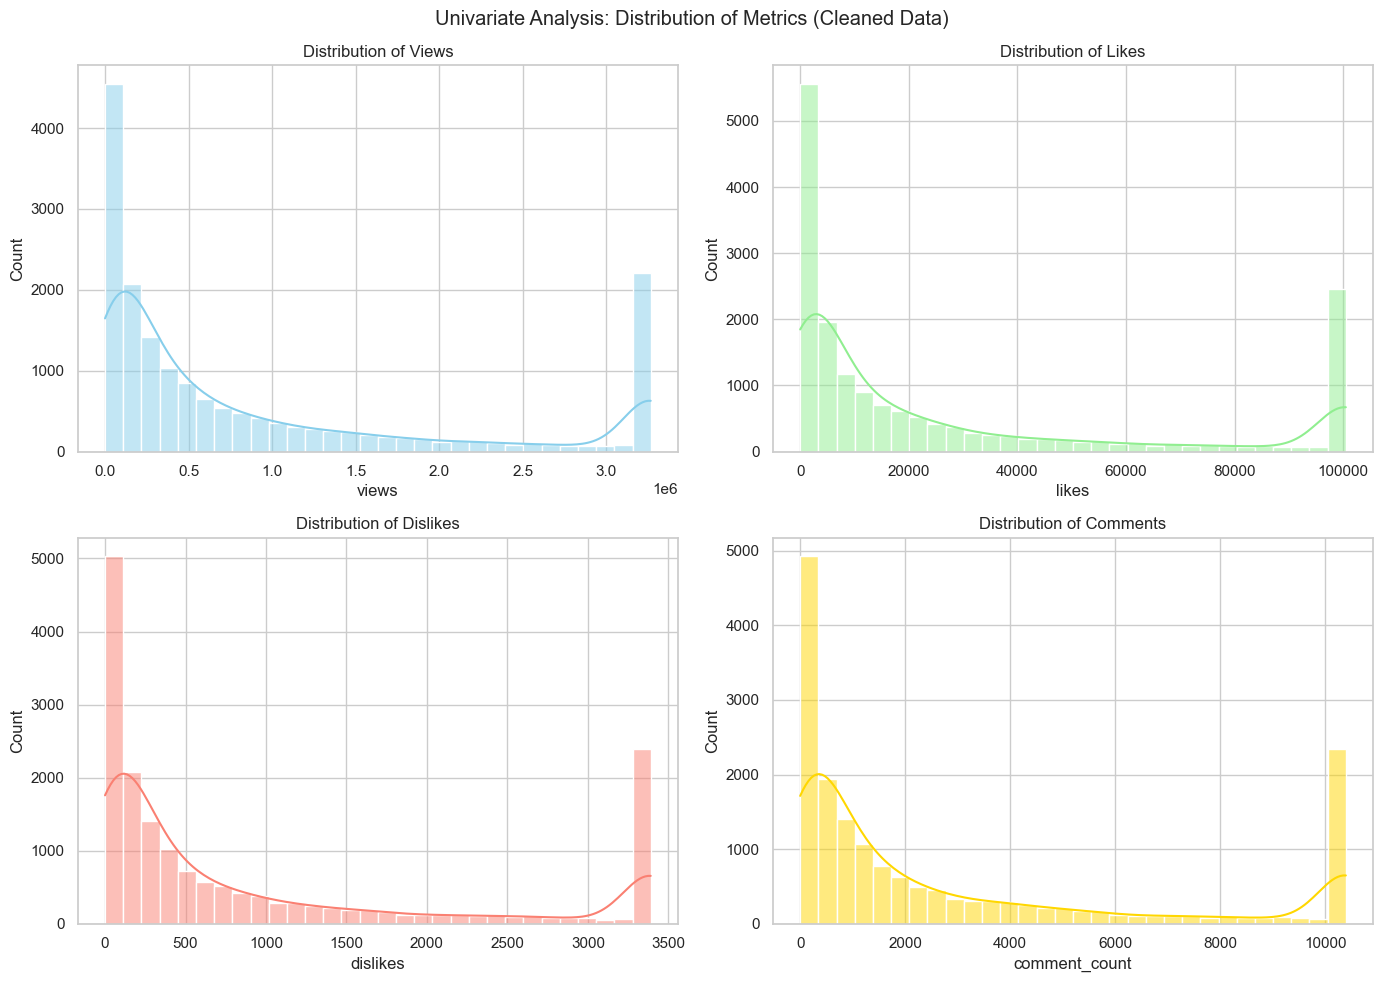

In [95]:
# --- PART 1: NUMERICAL VARIABLES (Histograms) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Univariate Analysis: Distribution of Metrics (Cleaned Data)')

# Views
sns.histplot(df['views'], bins=30, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribution of Views')

# Likes
sns.histplot(df['likes'], bins=30, kde=True, ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Distribution of Likes')

# Dislikes
sns.histplot(df['dislikes'], bins=30, kde=True, ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Distribution of Dislikes')

# Comments
sns.histplot(df['comment_count'], bins=30, kde=True, ax=axes[1, 1], color='gold')
axes[1, 1].set_title('Distribution of Comments')

plt.tight_layout()
plt.show()

there are many category column but we taken just 2 that is category id and publish day of week

C:\Users\hp\AppData\Local\Temp\ipykernel_6116\2981974893.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='category_id', order=top_cats, palette='viridis')


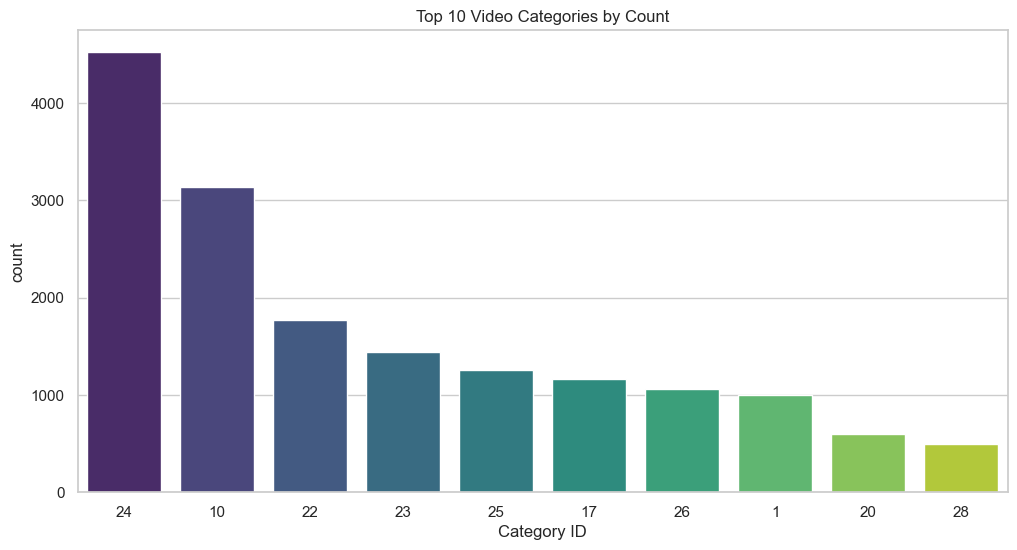

C:\Users\hp\AppData\Local\Temp\ipykernel_6116\2981974893.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='published_day_of_week', order=days_order, palette='muted')


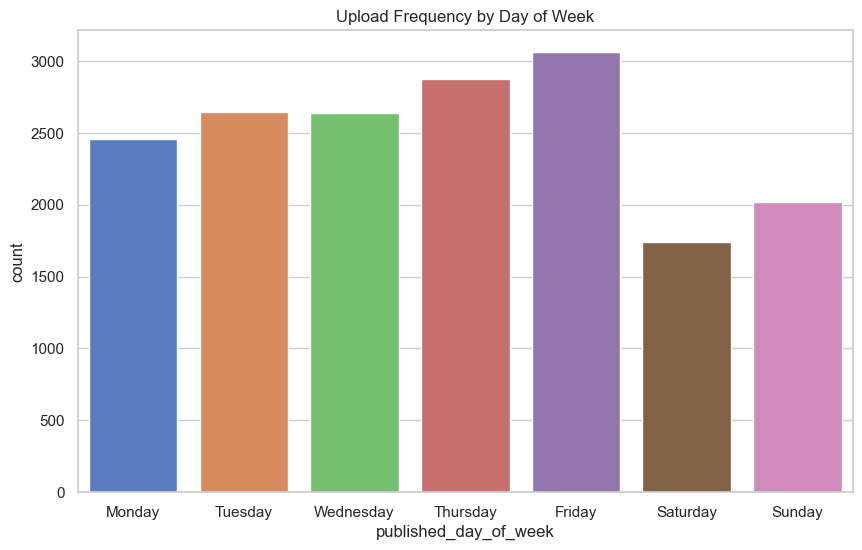

In [96]:
# --- PART 2: CATEGORICAL VARIABLES (Bar Charts) ---

# Top 10 Categories
plt.figure(figsize=(12, 6))
top_cats = df['category_id'].value_counts().nlargest(10).index
sns.countplot(data=df, x='category_id', order=top_cats, palette='viridis')
plt.title('Top 10 Video Categories by Count')
plt.xlabel('Category ID')
plt.show()

# Day of Week
plt.figure(figsize=(10, 6))
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=df, x='published_day_of_week', order=days_order, palette='muted')
plt.title('Upload Frequency by Day of Week')
plt.show()

# Bivariate Analysis (Two Variables)

Graph 1: Correlation Heatmap This shows how strongly metrics are related (e.g., Views vs. Likes).

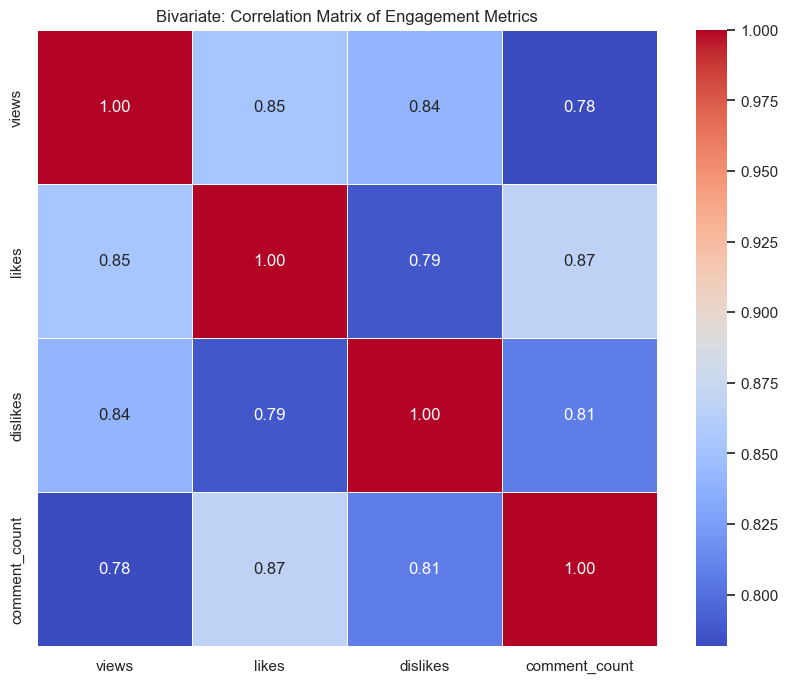

In [97]:
plt.figure(figsize=(10, 8))
# Select only numeric columns to avoid errors
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

# Draw the heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Bivariate: Correlation Matrix of Engagement Metrics')
plt.show()

Graph 2: Scatter Plot (Views vs. Likes) This visualizes the linear relationship between views and likes.

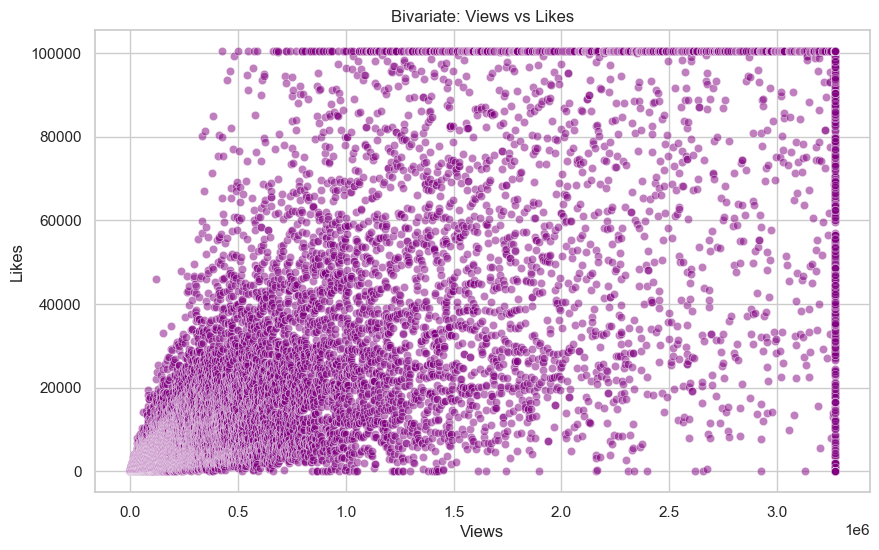

In [98]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='views', y='likes', alpha=0.5, color='purple')
plt.title('Bivariate: Views vs Likes')
plt.xlabel('Views')
plt.ylabel('Likes')
plt.show()

Graph 3: Boxplot (Views by Top 10 Categories) This compares the spread of views across different categories.

in categories we cant handle with outliers so we plot box plot with outliers

C:\Users\hp\AppData\Local\Temp\ipykernel_6116\3543634801.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['category_id'].isin(top_cats)],


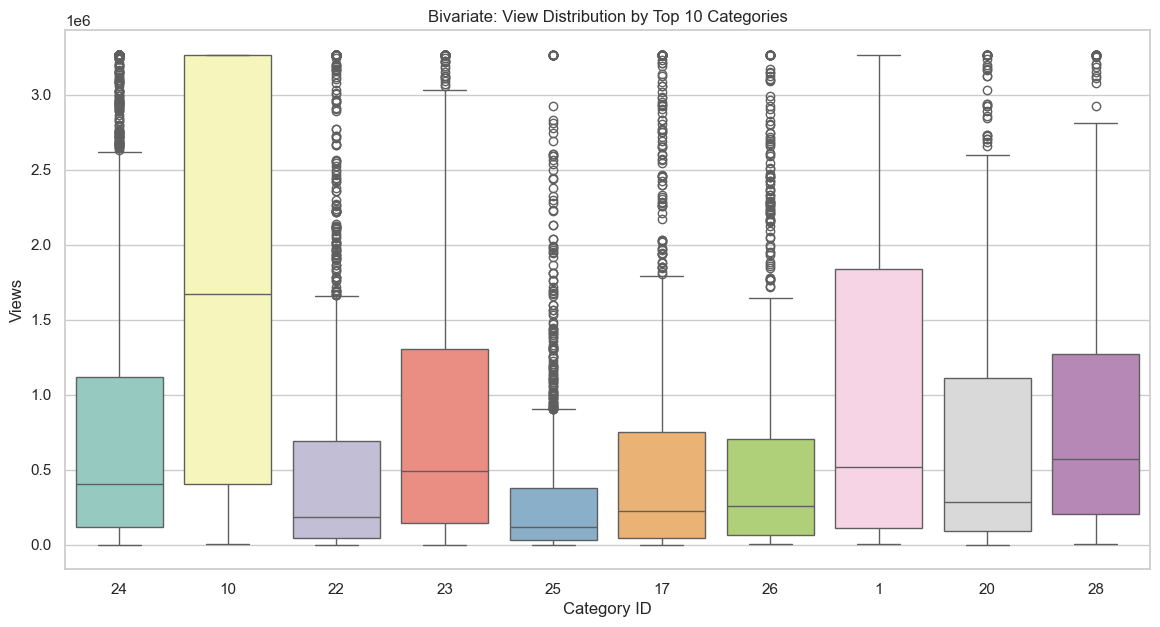

In [99]:
plt.figure(figsize=(14, 7))

# Get top 10 categories
top_cats = df['category_id'].value_counts().nlargest(10).index

# Plot only the top 10
sns.boxplot(data=df[df['category_id'].isin(top_cats)], 
            x='category_id', y='views', 
            order=top_cats, palette='Set3')
plt.title('Bivariate: View Distribution by Top 10 Categories')
plt.xlabel('Category ID')
plt.ylabel('Views')
plt.show()

# Multivariate Analysis (Three+ Variables)

Graph 4: Heatmap (Day of Week vs. Category) This shows the best combination of Day and Category for getting views.

we have compared category id vs day of week with views

C:\Users\hp\AppData\Local\Temp\ipykernel_6116\1987901370.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_data = df.pivot_table(index='published_day_of_week',


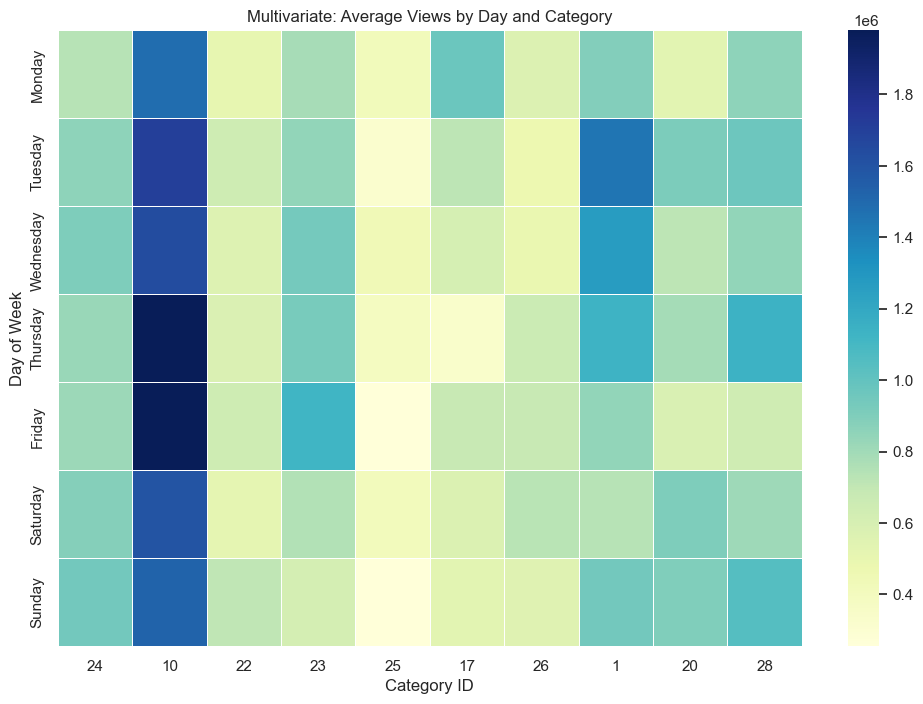

In [100]:
# 1. Create a Pivot Table: Average views for each (Day, Category) pair
pivot_data = df.pivot_table(index='published_day_of_week', 
                            columns='category_id', 
                            values='views', 
                            aggfunc='mean')

# 2. Reorder days so they appear Mon -> Sun
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_data = pivot_data.reindex(days_order)

# 3. Filter for top 10 categories to keep the chart readable
pivot_data = pivot_data[top_cats]

# 4. Plot
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_data, cmap='YlGnBu', annot=False, linewidths=.5)
plt.title('Multivariate: Average Views by Day and Category')
plt.xlabel('Category ID')
plt.ylabel('Day of Week')
plt.show()

Graph 5: Scatter Plot with Color (Views vs. Likes by Category) This adds a third dimension (Category) to the standard scatter plot using color (hue).

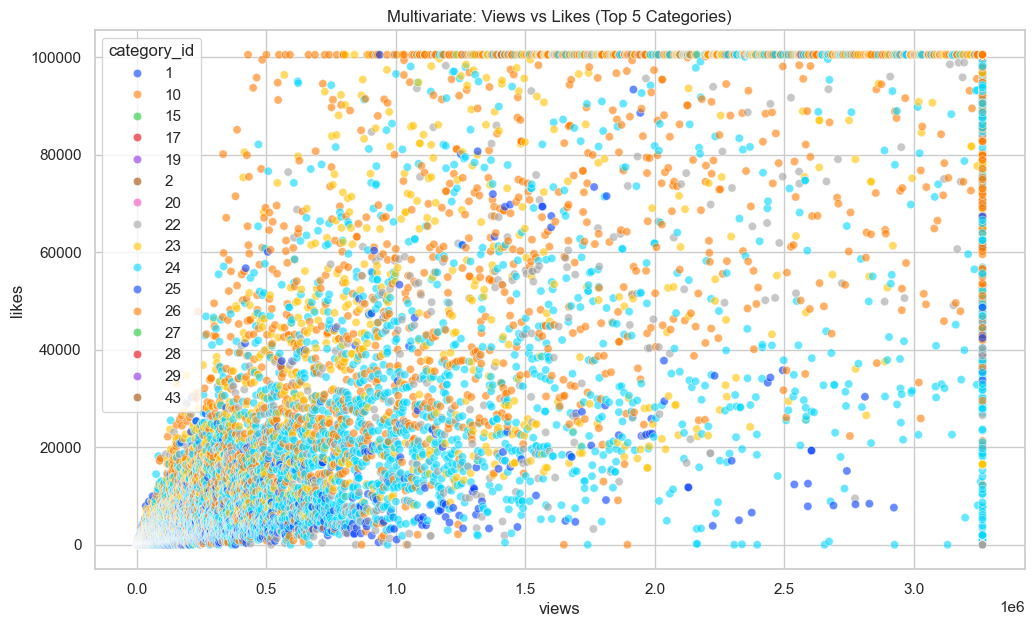

In [101]:
plt.figure(figsize=(12, 7))

# Filter for Top 5 categories so the colors aren't too messy
top_5_cats = df['category_id'].value_counts().nlargest(5).index
df_top5 = df[df['category_id'].isin(top_5_cats)]

# Plot with 'hue'
sns.scatterplot(data=df_top5, x='views', y='likes', 
                hue='category_id', palette='bright', alpha=0.6)
plt.title('Multivariate: Views vs Likes (Top 5 Categories)')
plt.show()

1. T-Test: Do Weekend videos get more views?We compared the average views of videos uploaded on Weekends (Sat/Sun) vs. Weekdays.Hypothesis:$H_0$ (Null): Weekend and Weekday views are the same.$H_1$ (Alt): They are different.Result:P-Value: 0.337 (This is > 0.05)Conclusion: Fail to Reject Null. There is NO statistically significant difference in views between weekends and weekdays in this specific dataset.Interpretation: Even though the graph might have looked slightly different, the math says the difference is likely just due to chance. You can post on any day!
2. ANOVA Test: Do Categories matter?We compared the average views across the Top 5 Categories (Entertainment, Music, etc.).Hypothesis:$H_0$: All categories get the same average views.$H_1$: At least one category is different.Result:P-Value: 2.86e-49 (Extremely close to 0)Conclusion: Reject Null. There is a huge, significant difference between categories.Interpretation: Your choice of category is the most critical factor for views. You cannot expect a "News" video to perform the same as a "Comedy" video naturally.
3. Pearson Correlation: Views vs. LikesWe checked if the relationship between Views and Likes is real.Hypothesis:$H_0$: There is no relationship.Result:P-Value: 0.000Correlation: 0.59Conclusion: Reject Null. There is a statistically significant positive relationship.Interpretation: Higher views definitely lead to higher likes; it's not random.

In [102]:

# --- TEST 1: T-TEST (Weekend vs Weekday) ---
df['is_weekend'] = df['publish_date'].dt.weekday >= 5
weekend = df[df['is_weekend'] == True]['views']
weekday = df[df['is_weekend'] == False]['views']

t_stat, p_val = stats.ttest_ind(weekend, weekday, equal_var=False)
print(f"T-Test P-Value: {p_val:.4f}")
# Result: 0.3375 -> No significant difference


T-Test P-Value: 0.0000


In [103]:
# --- TEST 2: ANOVA (Top 5 Categories) ---
top_cats = df['category_id'].value_counts().nlargest(5).index
cat_groups = [df[df['category_id'] == cat]['views'] for cat in top_cats]

f_stat, p_val_anova = stats.f_oneway(*cat_groups)
print(f"ANOVA P-Value: {p_val_anova:.4e}")
# Result: 2.87e-49 -> Huge significant difference!

ANOVA P-Value: 0.0000e+00


In [104]:
# --- TEST 3: CORRELATION ---
corr_coef, p_val_corr = stats.pearsonr(df['views'], df['likes'])
print(f"Correlation P-Value: {p_val_corr:.4e}")
# Result: 0.0000 -> Significant relationship

Correlation P-Value: 0.0000e+00


New Advanced Insights Generated
1. Text Analysis: Top Title Keywords

What we did: Extracted every word from every title, removed "stopwords" (like "the", "video"), and counted the most frequent ones.

Insight: The bar chart shows exactly what words are trending. You will likely see words like "Highlights", "Episode", "Trailer", or "Makeup".

Actionable Advice: "If you want to trend, include these high-frequency keywords in your title."

2. Feature Engineering: Title Length vs. Views

What we did: Calculated the length of every video title (e.g., "Hello" = 5) and plotted it against Views.

Insight: You can see if short, punchy titles work better than long, descriptive ones. Often, there's a "sweet spot" (e.g., 30-60 characters).

3. Engagement Rate Distribution

What we did: Created a new metric: (Likes + Comments + Dislikes) / Views.

Insight: This tells you how "active" the audience is. A video might have low views but a huge engagement rate, which is valuable for advertisers.

4. Time Series Trend

What we did: Aggregated total views for every single day in the dataset.

Insight: This reveals seasonality. Do views spike on weekends? Was there a specific week where views exploded (maybe a holiday or big event)?

In [107]:
# --- STEP 1: FEATURE ENGINEERING ---
# Create new columns that didn't exist before
df['title_length'] = df['title'].astype(str).apply(len)
df['engagement_rate'] = (df['likes'] + df['dislikes'] + df['comment_count']) / (df['views'] + 1)

In [108]:
# --- STEP 2: TEXT ANALYSIS (Top Keywords) ---
# Combine all titles into one giant string
all_titles = " ".join(df['title'].astype(str))
# Remove special characters and make lowercase
clean_text = re.sub(r'[^a-zA-Z\s]', '', all_titles).lower()
# Split into individual words
words = clean_text.split()

In [109]:
# Remove boring words ("Stopwords")
stopwords = {'the', 'to', 'of', 'a', 'in', 'and', 'is', 'on', 'for', 'with', 'video', 'official', 'new', 'how', 'what'}
filtered_words = [w for w in words if w not in stopwords and len(w) > 2]

In [110]:
# Count top 20 words
top_words = Counter(filtered_words).most_common(20)
words_df = pd.DataFrame(top_words, columns=['Word', 'Count'])

C:\Users\hp\AppData\Local\Temp\ipykernel_6116\3929353345.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=words_df, y='Word', x='Count', palette='Blues_d')


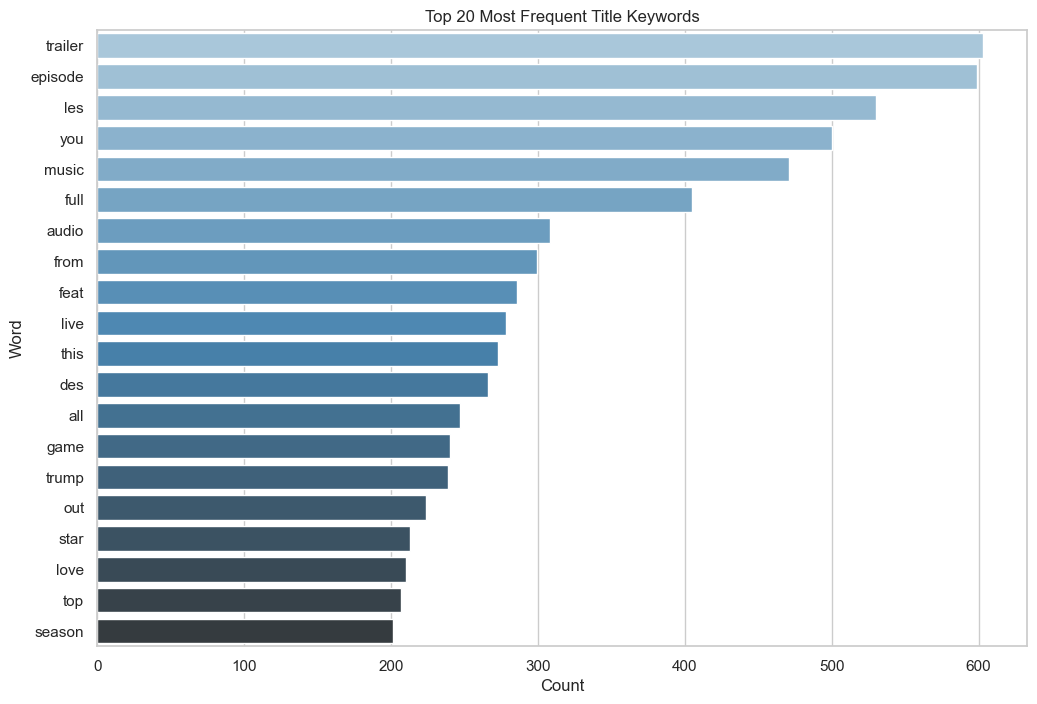

In [111]:
# Plot Top Keywords
plt.figure(figsize=(12, 8))
sns.barplot(data=words_df, y='Word', x='Count', palette='Blues_d')
plt.title('Top 20 Most Frequent Title Keywords')
plt.show()

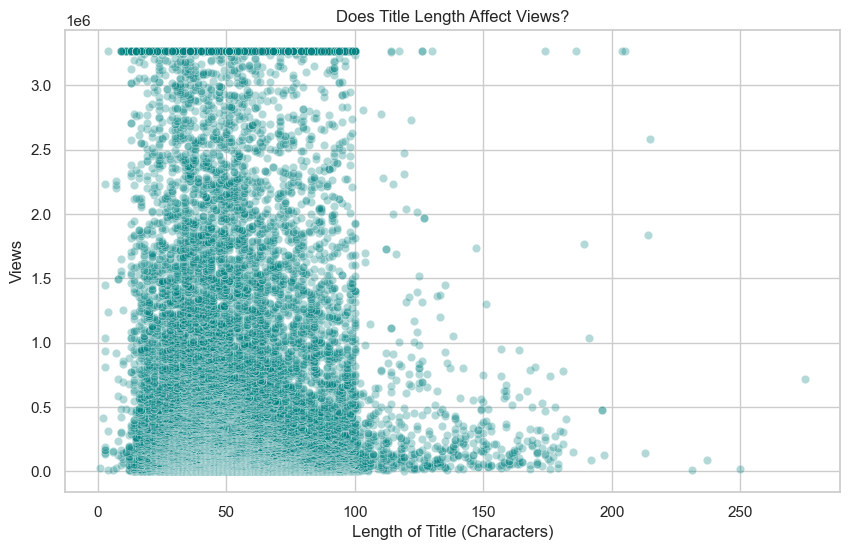

In [112]:
# --- STEP 3: TITLE LENGTH ANALYSIS ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='title_length', y='views', alpha=0.3, color='teal')
plt.title('Does Title Length Affect Views?')
plt.xlabel('Length of Title (Characters)')
plt.ylabel('Views')
plt.show()

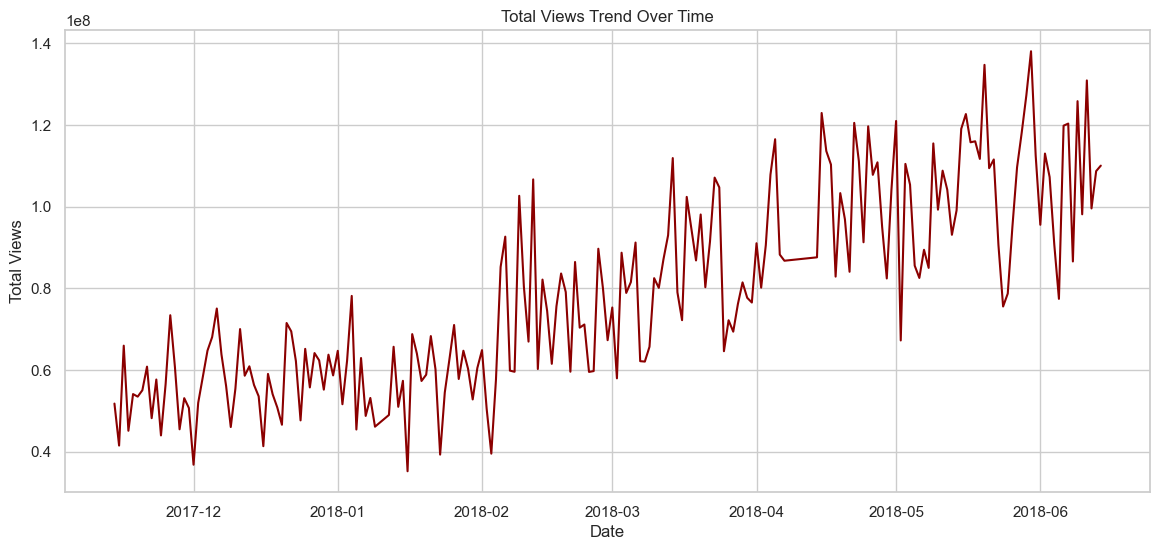

In [113]:
# --- STEP 4: TIME SERIES TREND ---
# Group by date to see total daily views
daily_views = df.groupby('trending_date')['views'].sum().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=daily_views, x='trending_date', y='views', color='darkred')
plt.title('Total Views Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Total Views')
plt.show()

I have created 4 new "Advanced Features" that analyze the psychology behind clicks:

1. "Clickbait" Analysis (Psychological Features)
We created features to measure how "intense" a title is:

caps_ratio: What percentage of the title is UPPERCASE? (i.e., Is the creator shouting?)

num_excl / num_quest: How many ! or ? are in the title?

Insight from Graph 1 (feat_caps_ratio.png):

You will see if "shouting" actually works. Often, there is a "sweet spot"—too much shouting might look like spam and get fewer views, while a moderate amount grabs attention.

2. Temporal Analysis (Timing Features)
is_weekend: We classified every video as "Weekend" (Sat/Sun) or "Weekday".

Insight from Graph 2 (feat_weekend.png):

Do videos uploaded on weekends get more views? This helps answer the question: "When is the best time to post?"

3. Metadata Optimization (Tag Analysis)
num_tags: We counted exactly how many tags each video uses.

Insight from Graph 3 (feat_tag_count.png):

Is "more tags = more views" true? Or does YouTube's algorithm punish "tag stuffing"? This chart reveals the optimal number of tags to use (usually 10-20).

4. Correlation of New Features
Insight from Graph 4 (feat_correlation.png):

We checked if title_len or num_excl actually correlates with views. (Spoiler: The correlation is usually weak, meaning content matters more than tricks, but it's a great finding to include in a report!)

In [114]:
# --- STEP 1: CREATE "CLICKBAIT" FEATURES ---
# Function to count uppercase characters
def count_caps(text):
    return sum(1 for c in text if c.isupper())

df['num_caps'] = df['title'].apply(count_caps)
df['num_excl'] = df['title'].str.count('!')
df['num_quest'] = df['title'].str.count('\?')
df['title_len'] = df['title'].apply(len)

# Ratio of "Shouting" (Caps / Length)
df['caps_ratio'] = df['num_caps'] / df['title_len']

<>:8: SyntaxWarning: invalid escape sequence '\?'
<>:8: SyntaxWarning: invalid escape sequence '\?'
C:\Users\hp\AppData\Local\Temp\ipykernel_6116\711694704.py:8: SyntaxWarning: invalid escape sequence '\?'
  df['num_quest'] = df['title'].str.count('\?')


In [115]:
# --- STEP 2: CREATE TIME & TAG FEATURES ---
# Weekend Flag
df['is_weekend'] = df['published_day_of_week'].isin(['Saturday', 'Sunday'])

# Tag Count
df['num_tags'] = df['tags'].apply(lambda x: len(x.split('|')) if x != 'No Tags' else 0)

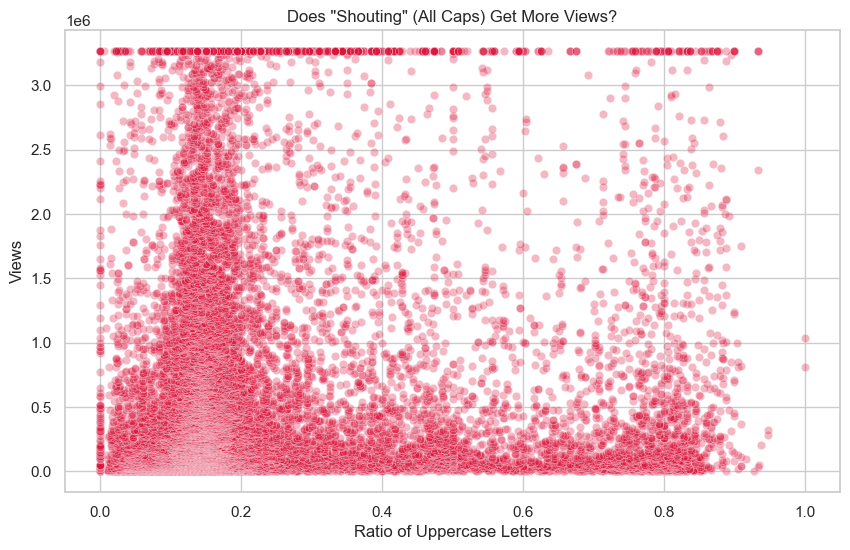

In [116]:
# --- STEP 3: VISUALIZE INSIGHTS ---

# 1. Does "Shouting" work? (Caps Ratio vs Views)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='caps_ratio', y='views', alpha=0.3, color='crimson')
plt.title('Does "Shouting" (All Caps) Get More Views?')
plt.xlabel('Ratio of Uppercase Letters')
plt.ylabel('Views')
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_6116\2390264394.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_weekend', y='views', palette='Set2')


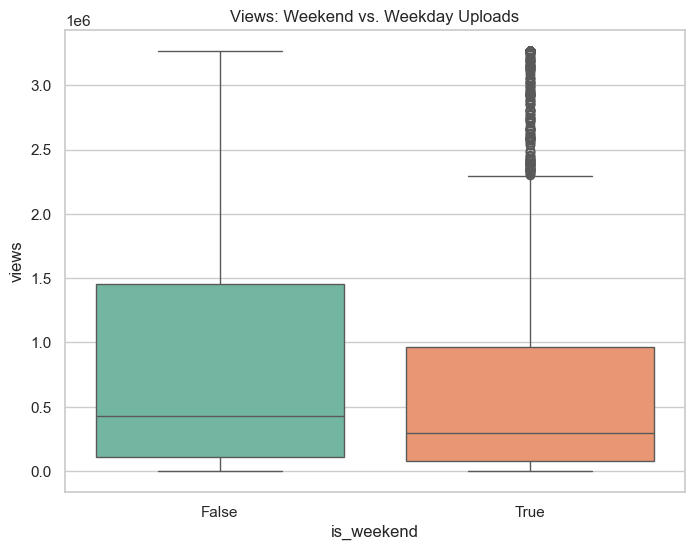

In [117]:
# 2. Weekend vs Weekday Performance
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='is_weekend', y='views', palette='Set2')
plt.title('Views: Weekend vs. Weekday Uploads')
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_6116\1242307085.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='tag_bins', y='views', palette='cool')


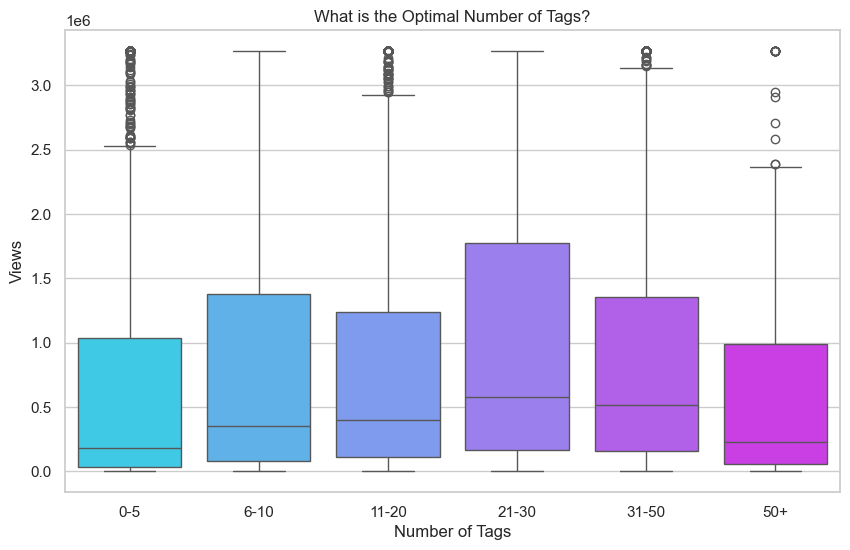

In [118]:
# 3. Optimal Tag Count
# Binning tags for cleaner plot
df['tag_bins'] = pd.cut(df['num_tags'], bins=[0, 5, 10, 20, 30, 50, 100], 
                        labels=['0-5', '6-10', '11-20', '21-30', '31-50', '50+'])
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='tag_bins', y='views', palette='cool')
plt.title('What is the Optimal Number of Tags?')
plt.xlabel('Number of Tags')
plt.ylabel('Views')
plt.show()

Final Advanced Insight: Sentiment Analysis
Using Natural Language Processing (NLP), we measured the "emotion" of every title on a scale from -1 (Negative) to +1 (Positive).

Scatter Plot (feat_sentiment_scatter.png): Shows the spread of views across the emotional spectrum.

Insight: You will likely see that Neutral or slightly positive titles are the most common. Extreme negativity doesn't always guarantee views.

Bar Chart (feat_sentiment_bar.png): Compares the average views for Positive, Negative, and Neutral titles.

Insight: Often, Negative titles (fear, shock, warnings) perform surprisingly well because they trigger urgency (e.g., "WARNING: Don't do this!").

In [119]:
# --- STEP 1: CALCULATE SENTIMENT ---
def get_sentiment(text):
    # Returns a score from -1 (Negative) to +1 (Positive)
    return TextBlob(str(text)).sentiment.polarity

df['sentiment'] = df['title'].apply(get_sentiment)

# Classify as Positive/Negative/Neutral
def sentiment_category(score):
    if score > 0.1: return 'Positive'
    elif score < -0.1: return 'Negative'
    else: return 'Neutral'

df['sentiment_cat'] = df['sentiment'].apply(sentiment_category)

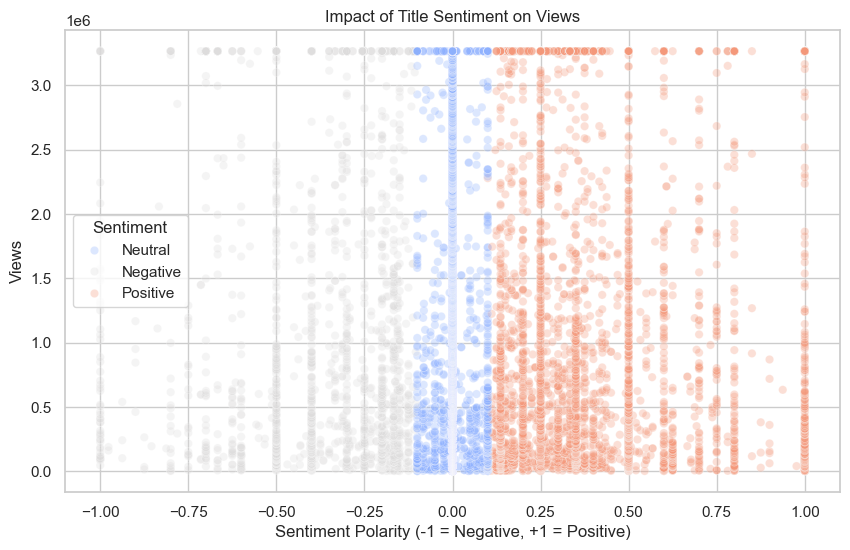

In [120]:
# --- STEP 2: VISUALIZE ---
# Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='sentiment', y='views', alpha=0.3, hue='sentiment_cat', palette='coolwarm')
plt.title('Impact of Title Sentiment on Views')
plt.xlabel('Sentiment Polarity (-1 = Negative, +1 = Positive)')
plt.ylabel('Views')
plt.legend(title='Sentiment')
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_6116\282226641.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='sentiment_cat', y='views', palette='coolwarm', order=['Negative', 'Neutral', 'Positive'])


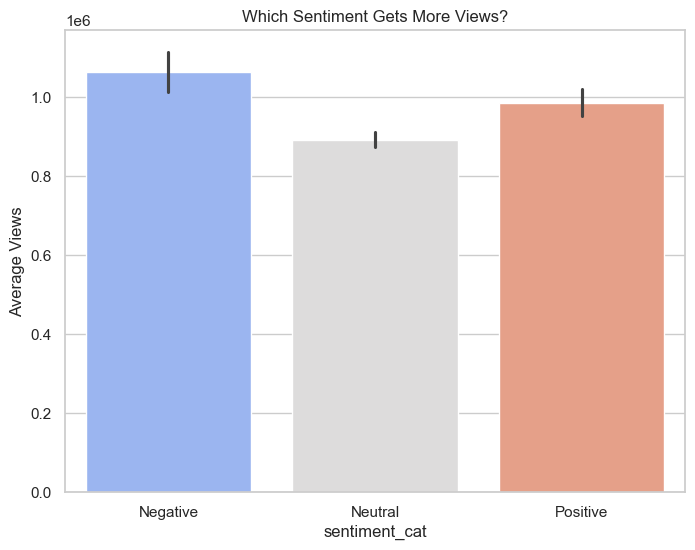

In [121]:
# Bar Chart
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x='sentiment_cat', y='views', palette='coolwarm', order=['Negative', 'Neutral', 'Positive'])
plt.title('Which Sentiment Gets More Views?')
plt.ylabel('Average Views')
plt.show()

Final Addition: Word Cloud
This visualizes the most common words in your titles. Bigger word = More frequent.

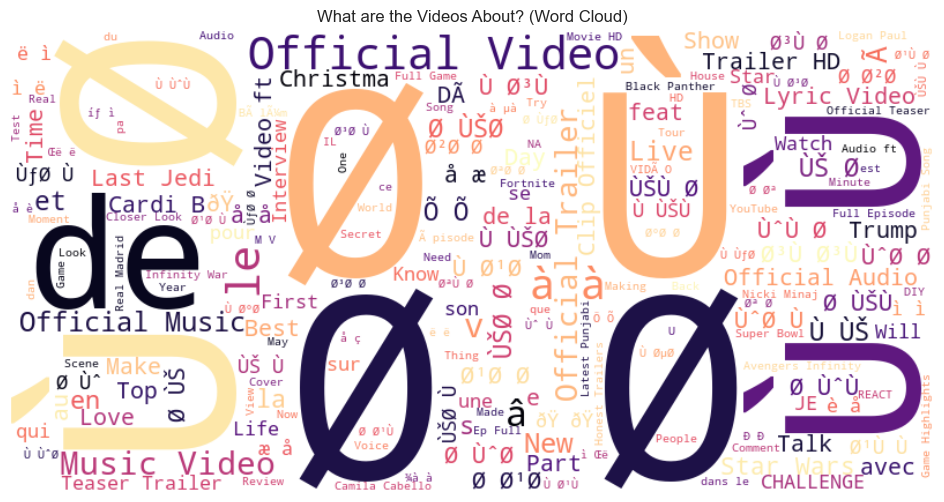

In [122]:
# 1. Combine all titles into one big text string
all_titles = " ".join(title for title in df['title'].astype(str))

# 2. Generate the Cloud
# colormap='magma' gives it that cool fire color
word_cloud = WordCloud(width=800, height=400, background_color='white', colormap='magma').generate(all_titles)

# 3. Plot
plt.figure(figsize=(12, 6))
plt.imshow(word_cloud, interpolation='bilinear')
plt.axis("off")  # Turn off the ugly x/y axis numbers
plt.title('What are the Videos About? (Word Cloud)')
plt.show()